## Convenience functions

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
import torchvision
from PIL import Image


def plot_forward_diffusion(x, timesteps=None, figsize=None):
    """Given a batch of images x, create a nice plot with optional timesteps below each image"""
    x = x * 0.5 + 0.5  # Map from (-1, 1) back to (0, 1)
    x = x.detach().cpu().clip(0, 1)
    
    n_images = x.shape[0]
    
    if figsize is None:
        figsize = (2 * n_images, 2.5 if timesteps is not None else 2)
    
    fig, axes = plt.subplots(1, n_images, figsize=figsize)
    
    # Handle single image case
    if n_images == 1:
        axes = [axes]
    
    for idx, ax in enumerate(axes):
        img = x[idx].permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.axis('off')
        
        if timesteps is not None:
            timestep_val = timesteps[idx].item() if torch.is_tensor(timesteps[idx]) else timesteps[idx]
            ax.set_title(f't = {timestep_val}', fontsize=10, pad=5)
    
    plt.tight_layout()
    return fig


def make_grid(images, size=64):
    """Given a list of PIL images, stack them together into a line for easy viewing"""
    output_im = Image.new("RGB", (size * len(images), size))
    for i, im in enumerate(images):
        output_im.paste(im.resize((size, size)), (i * size, 0))
    return output_im


# Mac users may need device = 'mps' (untested)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Clear CUDA cache and set debugging
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'  # Enable device-side assertions for better error messages

import torch

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"CUDA available: {torch.cuda.is_available()}")
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    print(f"CUDA_LAUNCH_BLOCKING: {os.environ.get('CUDA_LAUNCH_BLOCKING')}")
    print(f"TORCH_USE_CUDA_DSA: {os.environ.get('TORCH_USE_CUDA_DSA')}")

CUDA available: True
CUDA device: NVIDIA GeForce RTX 5070 Ti
CUDA memory allocated: 0.00 MB
CUDA_LAUNCH_BLOCKING: 1
TORCH_USE_CUDA_DSA: 1


## Load dataset

In [3]:
data_dir = "/home/ap/cloud/ARIS/Collection_Sorting/2025-04-08_2025-11-30_prod-data_bold-eagle_NOT-STARTED/normal_wood"


In [4]:
import torchvision
from datasets import load_dataset
from torchvision import transforms
import torch


# Or load images from a local folder
dataset = load_dataset("imagefolder", data_dir=data_dir, split="train")


# We'll train on 128-pixel square images, but you can try larger sizes too
# You can lower your batch size if you're running out of GPU memory

# Define data augmentations
preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),  # Resize
        transforms.RandomHorizontalFlip(),  # Randomly flip (data augmentation)
        transforms.ToTensor(),  # Convert to tensor (0, 1)
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # Map to (-1, 1) for RGB
    ]
)


def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}


dataset.set_transform(transform)

# Create a dataloader from the dataset to serve up the transformed images in batches
train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True    
)

print(f"Dataset size: {len(dataset)}")
print(dataset)
xb = next(iter(train_dataloader))["images"].to(device)[:8]
print("X shape:", xb.shape)
xb = xb[0:1].repeat(5, 1, 1, 1)
plot_forward_diffusion(xb)
plt.show()


Resolving data files:   0%|          | 0/618 [00:00<?, ?it/s]

NameError: name 'image_size' is not defined

## Forward diffusion figure

### ARIS Image

In [55]:
aris_image_path = "/home/ap/cloud/ARIS/Collection_Sorting/2025-04-08_2025-11-30_prod-data_bold-eagle_NOT-STARTED/normal_wood/img_bold-eagle_2025-04-17T20-11-38-359.png"
image_size = 512
batch_size = 64
n_imgs = 6
use_ARIS_image = True

In [56]:

def plot_forward_diffusion(noisy_xb, timesteps, figsize=None, n_imgs=5, is_grayscale=False, normalize=True):
    """
    Plot forward diffusion process with timesteps below each image
    
    Args:
        noisy_xb: torch.Tensor of noisy images
        timesteps: Timesteps for each image
        figsize: Figure size (optional)
        n_imgs: Number of images to show
        is_grayscale: If True, treats image as grayscale/binary (single channel)
        normalize: If True, applies normalization from [-1, 1] to [0, 1]. Set False if already in [0, 1]
    """
    
    # Only normalize if input is in [-1, 1] range
    if normalize:
        noisy_xb = noisy_xb * 0.5 + 0.5  # Map from (-1, 1) back to (0, 1)
    
    noisy_xb = noisy_xb.detach().cpu().clip(0, 1)
    
    n_images = min(noisy_xb.shape[0], n_imgs)
    
    if figsize is None:
        figsize = (2 * n_images, 2.5 if timesteps is not None else 2)
    
    fig, axes = plt.subplots(1, n_images, figsize=figsize)
    
    # Handle single image case
    if n_images == 1:
        axes = [axes]
    
    for idx, ax in enumerate(axes):
        if is_grayscale:
            # Display as grayscale (single channel) - use 'Greys' to match matplotlib style
            img = noisy_xb[idx].squeeze().numpy()  # Remove channel dimension
            ax.imshow(img, cmap='Greys', vmin=0, vmax=1)
        else:
            # Display as RGB
            img = noisy_xb[idx].permute(1, 2, 0).numpy()
            ax.imshow(img)
        
        ax.axis('off')
        
        if timesteps is not None:
            timestep_val = timesteps[idx].item() if torch.is_tensor(timesteps[idx]) else timesteps[idx]
            ax.set_title(f'{timestep_val}', fontsize=10, pad=5)
    
    #plt.tight_layout()
    return fig


/home/ap/cloud/Master/aris_master/.venv/lib/python3.11/site-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


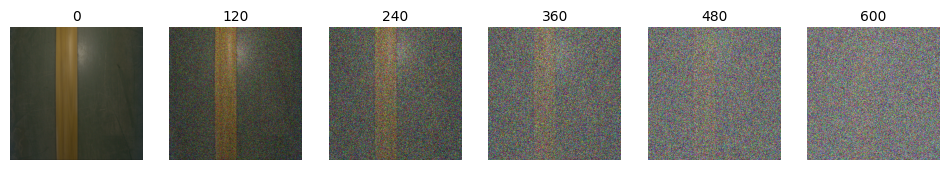

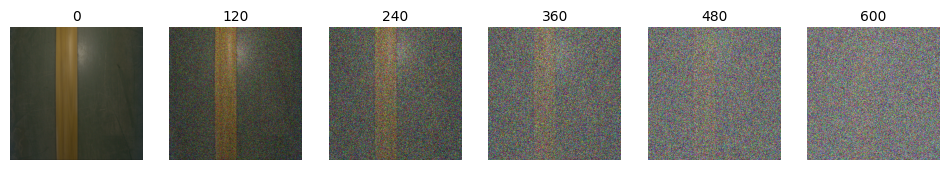

In [57]:
from diffusers import DDPMScheduler
import torch
import PIL.Image as Image
from torchvision import transforms
import torchvision
import matplotlib.pyplot as plt
# Load in image and turn it into a tensor of shape (B, C, H, W) with values in the range (-1, 1)
image = Image.open(aris_image_path).convert("RGB")

#plot_forward_diffusion(image)


# Don't repeat to 3 channels - keep as grayscale

# Noise scheduler
noise_scheduler = DDPMScheduler(num_train_timesteps=1001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    

# Transform
preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),  # Resize
        transforms.ToTensor(),  # Convert to tensor (0, 1)
        transforms.Normalize([0.5], [0.5]),  # Map to (-1, 1)
    ]
)

# Convert to appropriate mode (L for grayscale, RGB for color)
xb = preprocess(image).unsqueeze(0).to(device)  # Shape (1, C, H, W)

xb = xb.repeat(n_imgs, 1, 1, 1)  # Shape (n_imgs, C, H, W)

# Add noise to the image using the noise scheduler
noise = torch.randn_like(xb)
timesteps = torch.linspace(0, (noise_scheduler.num_train_timesteps - 1)*0.6, n_imgs).long().to(device)
xb_noisy = noise_scheduler.add_noise(xb, noise, timesteps)


plot_forward_diffusion(xb_noisy, timesteps=timesteps,n_imgs=n_imgs)  # RGB image



Input shape: torch.Size([6, 1, 28, 28])
Labels: tensor([9, 5, 2, 3, 8])


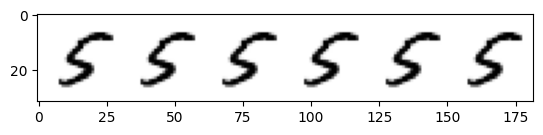

In [137]:
dataset = torchvision.datasets.MNIST(root="mnist/", train=True, download=True, transform=torchvision.transforms.ToTensor())
train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=5, shuffle=True)
x, y = next(iter(train_dataloader))
# Repeat x
x = x[1].repeat(n_imgs, 1, 1, 1)  # Shape (5, 1, 28, 28)
print('Input shape:', x.shape)
print('Labels:', y)
plt.imshow(torchvision.utils.make_grid(x)[0], cmap='Greys');


In [138]:
def corrupt(x, amount):
    """Corrupt the input tensor x with noise based on the amount."""
    noise = torch.rand_like(x, device=x.device)  # Ensure noise is on the same device as x
    amount = amount.to(x.device)  # Move amount to the same device as x
    amount = amount.view(-1, 1, 1, 1)  # Reshape for broadcasting
    return x * (1 - amount) + noise * amount

Amount shape: tensor([0.0000, 0.2000, 0.4000, 0.6000, 0.8000, 1.0000])


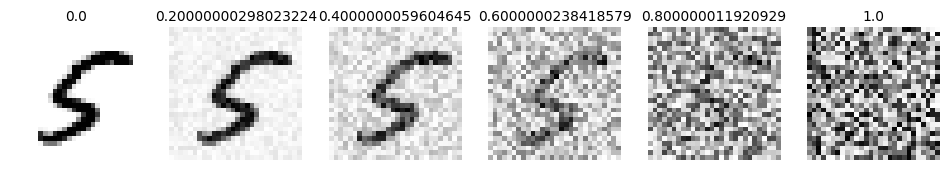

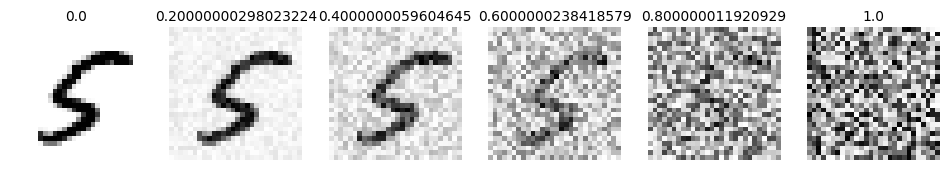

In [139]:
# Adding noise
amount = torch.linspace(0, 1, x.shape[0])  # Left to right -> more corruption
print('Amount shape:', amount)
noised_x = corrupt(x, amount)
# 
plot_forward_diffusion(noised_x, timesteps=amount, n_imgs=n_imgs, is_grayscale=True, normalize=False) 


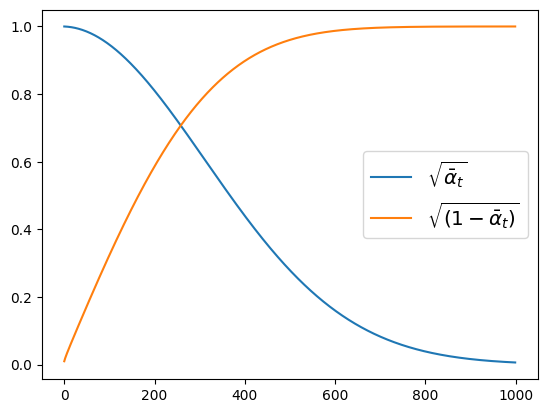

In [84]:
# Use a linear noise schedule, which is the default for DDPMScheduler. You can try other schedules too (cosine, sigmoid, etc.)
noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear")
plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large");